# From SaccadeJEPA to GazeJEPA

This notebook explains the change as a simple path:

1. What original SaccadeJEPA did.
2. What we replaced.
3. How saliency, multiple fixations, and inhibition of return change the behavior.
4. What stayed the same from JEPA.
5. How we check that the changed model still learns.

## The core idea

Original SaccadeJEPA was useful, but its "saccade" was not really a gaze
decision. It picked a random spatial crop pair and learned to predict one
representation from the other.

```text
original SaccadeJEPA:
image -> one random crop/shift -> encode -> predict representation
```

Our version keeps the JEPA prediction idea, but changes where the crops
come from.

```text
GazeJEPA:
image -> saliency map -> fixation 1 -> fixation 2 -> ... -> JEPA prediction
```

So the short version is:

**we kept the JEPA model, but replaced the random cropper with a gaze cropper.**

In [10]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

REPO = Path.cwd().resolve()
if REPO.name == "notebooks":
    REPO = REPO.parent
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from gazejepa.data import get_split, load_frame, resolve_data_root
from gazejepa.gaze_loop import GazeLoop
from gazejepa.jepa_reuse import make_gaze_jepa
from gazejepa.jepa_reuse.saccade_jepa import SaccadeJepa
from gazejepa.saliency import IttiKochSaliency, ResNetSaliency

torch.manual_seed(42)
np.random.seed(42)

FULL_INPUT = (200, 200)
MODEL_INPUT = (128, 128)
T = 5

## Step 1 - What the original model did

Original SaccadeJEPA does not look around an image like a human. It takes
one image, creates a random shifted crop pair, and asks the predictor to
predict the target representation.


```text
take image
pick one random spatial change
make crop A and crop B
encode crop A
predict the representation of crop B
```

That is a valid self-supervised learning task, but it is not yet an
explicit gaze simulation.

In [11]:
base_model = SaccadeJepa(
    full_input_size=FULL_INPUT,
    model_input_size=MODEL_INPUT,
)

print(f"Model class:   {type(base_model).__name__}")
print(f"Cropper class: {type(base_model.saccade_cropper).__name__}")
print(f"Cropper output embedding width: {base_model.saccade_cropper.affine_embed_dim}")

Model class:   SaccadeJepa
Cropper class: SaccadeCropper
Cropper output embedding width: 36


## Step 2 - The one part we changed

We did not rewrite SaccadeJEPA. The important change is this:

```python
model.saccade_cropper = GazeCropper(...)
```

The model is still a `SaccadeJepa` object. The encoder is still there.
The predictor is still there. The EMA target encoder is still there.

Only the cropper changes:

```text
before: random cropper
after:  saliency + IOR gaze cropper
```

In [12]:
resnet_ckpt = REPO / "checkpoints" / "resnet_saliency_best.pt"
if resnet_ckpt.is_file():
    saliency = ResNetSaliency.load(str(resnet_ckpt))
    saliency_name = "ResNetSaliency"
else:
    saliency = IttiKochSaliency()
    saliency_name = "IttiKochSaliency fallback"

gaze_model = make_gaze_jepa(
    saliency_source=saliency,
    full_input_size=FULL_INPUT,
    model_input_size=MODEL_INPUT,
    n_fixations=T,
    ior_sigma=20.0,
    ior_decay=0.7,
    sampling_mode="argmax",  # deterministic for notebook figures
)
gaze_model.eval()

print(f"Saliency source:       {saliency_name}")
print(f"Model class:           {type(gaze_model).__name__}")
print(f"Old cropper class:     {type(base_model.saccade_cropper).__name__}")
print(f"New cropper class:     {type(gaze_model.saccade_cropper).__name__}")
print(f"Cropper embedding dim: {gaze_model.saccade_cropper.affine_embed_dim}")
print(f"Affine embedder input: {gaze_model.affine_embedder[1].in_features}")

Saliency source:       ResNetSaliency
Model class:           SaccadeJepa
Old cropper class:     SaccadeCropper
New cropper class:     GazeCropper
Cropper embedding dim: 36
Affine embedder input: 36


## Step 3 - Start from an image

The notebook uses a FIND video frame when the dataset is available.

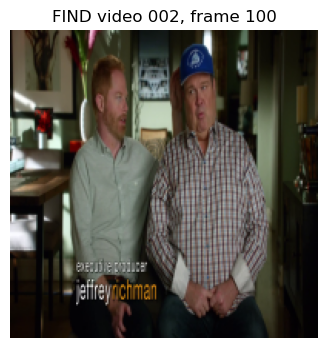

In [ ]:
def load_demo_image() -> tuple[torch.Tensor, str]:
    try:
        data_root = resolve_data_root()
        split = get_split(data_root, seed=42)
        video_id = split["test"][0]
        frame = load_frame(data_root, video_id, frame_idx=100, size=FULL_INPUT[0])
        image = torch.from_numpy(frame).permute(2, 0, 1).float() / 255.0
        return image, f"FIND video {video_id}, frame 100"
    except Exception:
        raise RuntimeError(
            "Failed to load demo image from FIND dataset. Please ensure the dataset is available and properly set up."
)
        
image, image_title = load_demo_image()

plt.figure(figsize=(4, 4))
plt.imshow(image.permute(1, 2, 0).numpy())
plt.title(image_title)
plt.axis("off")
plt.show()

## Step 4 - Random location becomes saliency

Original SaccadeJEPA picks a crop location randomly.

GazeJEPA first computes a saliency map. The saliency map is a simple
answer to:

```text
where does this image look visually important?
```


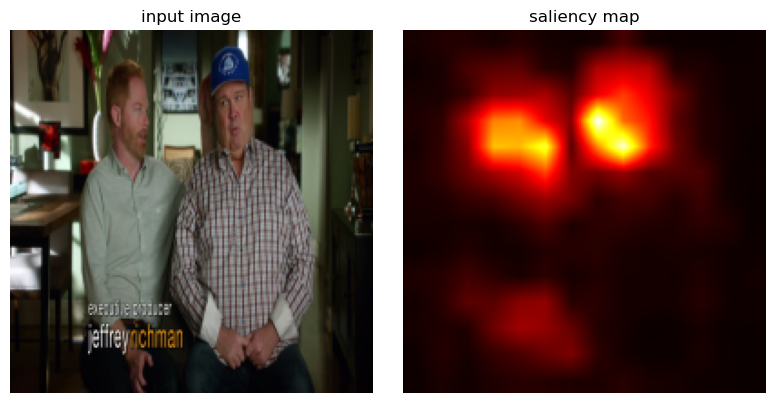

In [16]:
with torch.no_grad():
    saliency_map = saliency(image.unsqueeze(0).float())[0].cpu()

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(image.permute(1, 2, 0).numpy())
axes[0].set_title("input image")
axes[0].axis("off")

axes[1].imshow(saliency_map.numpy(), cmap="hot")
axes[1].set_title("saliency map")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Step 5 - One crop becomes a fixation sequence

Original SaccadeJEPA creates one crop pair.

GazeJEPA creates a short scanpath:

```text
fixation 1 -> fixation 2 -> fixation 3 -> fixation 4 -> fixation 5
```

Each neighboring pair becomes a JEPA transition:

```text
fix_1 -> fix_2
fix_2 -> fix_3
fix_3 -> fix_4
fix_4 -> fix_5
```

With `T = 5`, one image gives `T - 1 = 4` prediction examples.

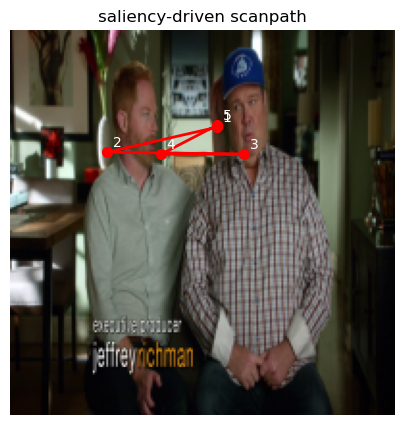

Scanpath points:
  fixation 1: x=107.0, y=50.0
  fixation 2: x=50.0, y=63.0
  fixation 3: x=121.0, y=64.0
  fixation 4: x=78.0, y=64.0
  fixation 5: x=107.0, y=49.0


In [17]:
loop = GazeLoop(
    saliency_source=saliency,
    n_fixations=T,
    image_size=FULL_INPUT,
    ior_sigma=20.0,
    ior_decay=0.7,
    sampling_mode="argmax",
)
loop_result = loop(image)

scanpath = loop_result["scanpath"].cpu().numpy()

plt.figure(figsize=(5, 5))
plt.imshow(image.permute(1, 2, 0).numpy())
plt.plot(scanpath[:, 0], scanpath[:, 1], "ro-", linewidth=2, markersize=7)
for i, (x, y) in enumerate(scanpath, start=1):
    plt.annotate(
        str(i),
        (x, y),
        color="white",
        fontsize=10,
        xytext=(4, 4),
        textcoords="offset points",
    )
plt.title("saliency-driven scanpath")
plt.axis("off")
plt.show()

print("Scanpath points:")
for i, (x, y) in enumerate(scanpath, start=1):
    print(f"  fixation {i}: x={x:.1f}, y={y:.1f}")

## Step 6 - Do not immediately look back

Human gaze usually does not jump back to the exact same point again and
again. We model that with inhibition of return, or IOR.

```text
after the model looks somewhere,
temporarily make that area less attractive,
so the next fixation moves somewhere new.
```

The saliency map says where the image is interesting. The IOR mask says
where the model has already looked recently.

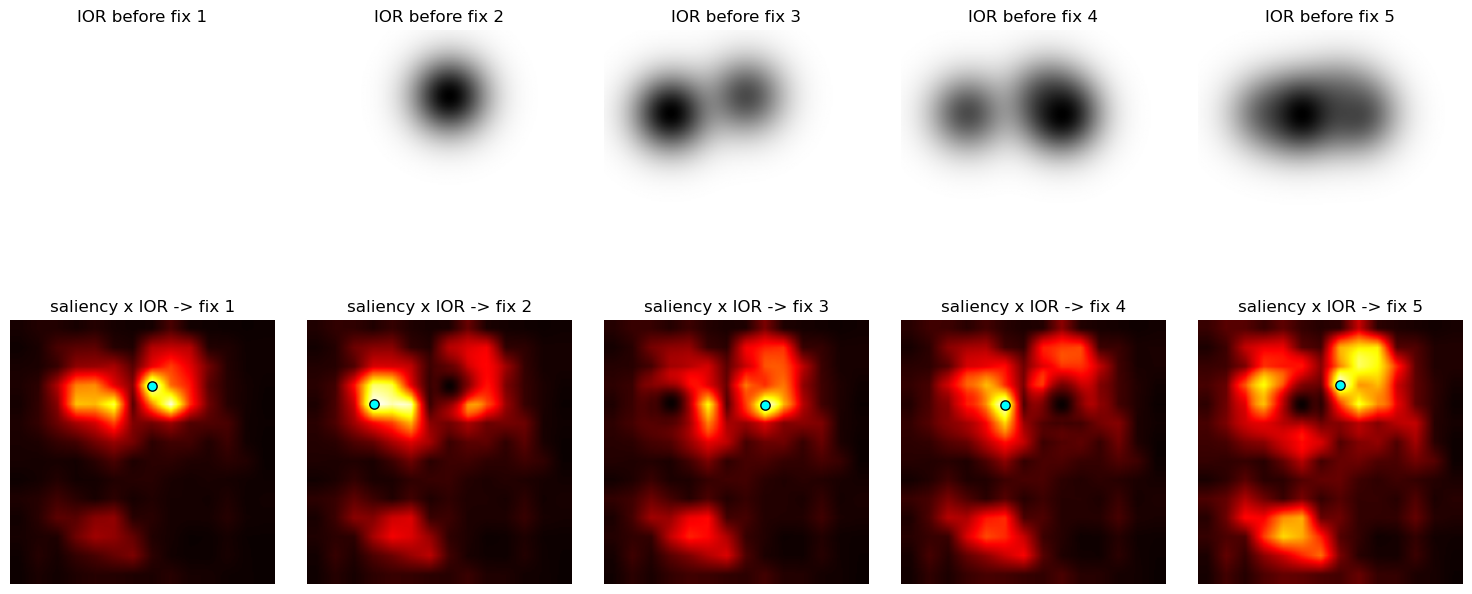

In [18]:
ior_history = loop_result["ior_history"].cpu()

fig, axes = plt.subplots(2, T, figsize=(3 * T, 6))
for t in range(T):
    effective = saliency_map * ior_history[t]
    effective = effective / effective.max().clamp_min(1e-8)

    axes[0, t].imshow(ior_history[t].numpy(), cmap="gray", vmin=0, vmax=1)
    axes[0, t].set_title(f"IOR before fix {t + 1}")
    axes[0, t].axis("off")

    axes[1, t].imshow(effective.numpy(), cmap="hot")
    axes[1, t].scatter(
        [scanpath[t, 0]],
        [scanpath[t, 1]],
        c="cyan",
        s=45,
        edgecolors="black",
    )
    axes[1, t].set_title(f"saliency x IOR -> fix {t + 1}")
    axes[1, t].axis("off")

plt.tight_layout()
plt.show()

## Step 7 - The JEPA learning task stays the same

After the cropper creates neighboring fixation crops, the rest is still
SaccadeJEPA:

```text
crop at fixation t       -> context encoder
crop at fixation t + 1   -> EMA target encoder
displacement t -> t + 1  -> affine embedding
predictor output         -> should match target representation
```

The target encoder is the EMA part: a slow-moving copy of the context
encoder. We did not change that mechanism.

In [20]:
with torch.no_grad():
    target, context_copy, target_pred, cycle_loss = gaze_model(image.unsqueeze(0))

print(f"target shape:       {tuple(target.shape)}")
print(f"context shape:      {tuple(context_copy.shape)}")
print(f"prediction shape:   {tuple(target_pred.shape)}")
print(f"cycle loss:         {float(cycle_loss):.4f}")
print(f"transitions/image:  {T - 1}")
print(f"batch rows created: {target.shape[0]}")
print()
print("Prediction MSE before/without loading a trained checkpoint:",
      f"{torch.nn.functional.mse_loss(target_pred, target).item():.4f}")

target shape:       (4, 1536)
context shape:      (4, 1536)
prediction shape:   (4, 1536)
cycle loss:         0.2940
transitions/image:  4
batch rows created: 4

Prediction MSE before/without loading a trained checkpoint: 0.2947


## Step 8 - How we know the change works

The important question is not only whether the code runs. The question is:

```text
can the same JEPA loss still train the predictor after this cropper swap?
```

The training script keeps the upstream Huber + cycle + VICReg recipe and
trains on FIND frames. The metric below is prediction MSE: lower is
better.

Loaded training history: /Volumes/Mac/UniProjects/gaze-jepa/outputs/jepa_reuse/metrics/history.json
  epoch 1: val prediction MSE = 0.0963
  epoch 2: val prediction MSE = 0.0471
  epoch 3: val prediction MSE = 0.0459
  epoch 4: val prediction MSE = 0.0428
  epoch 5: val prediction MSE = 0.0447

Change from epoch 1 to final epoch: +38.5%


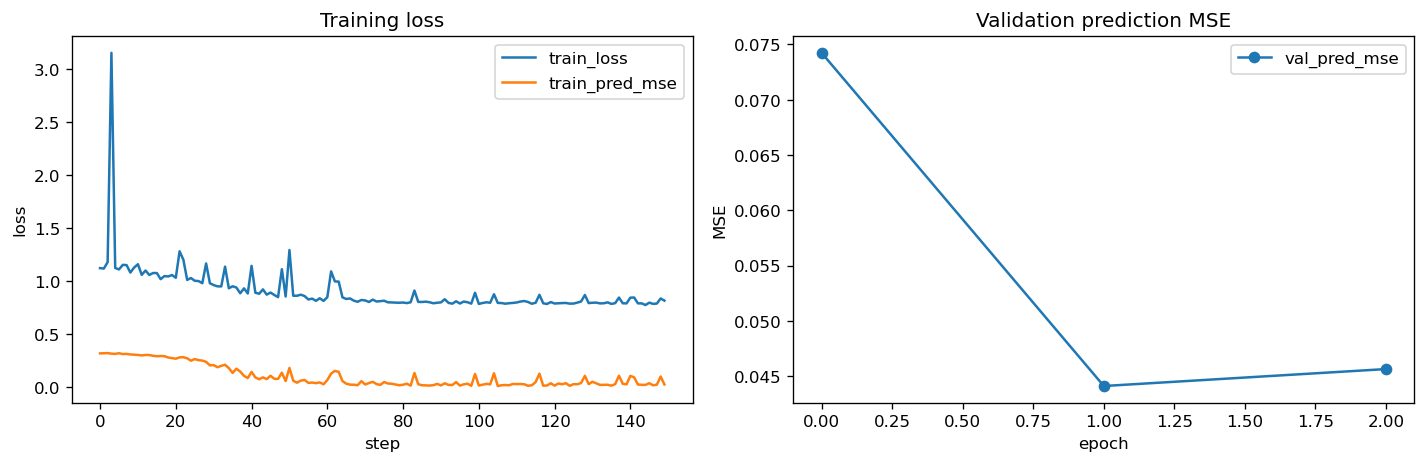

In [ ]:
import json as _json

history_path = REPO / "outputs/jepa_reuse/metrics/history.json"
loss_curve_path = REPO / "outputs/jepa_reuse/metrics/loss_curve.png"

if history_path.is_file():
    history = _json.loads(history_path.read_text())
    val_mse = history.get("val_pred_mse", [])

    print(f"Loaded training history: {history_path}")
    for epoch, value in enumerate(val_mse, start=1):
        print(f"  epoch {epoch}: val prediction MSE = {value:.4f}")

    if len(val_mse) >= 2:
        change = (val_mse[0] - val_mse[-1]) / val_mse[0] * 100.0
        print(f"\nChange from epoch 1 to final epoch: {change:+.1f}%")

    if loss_curve_path.is_file():
        from IPython.display import Image, display

        display(Image(str(loss_curve_path)))
else:
    print("No training history found yet.")
    print("Run this from the repo root to create it:")
    print("  conda run -n gaze-jepa python scripts/train_jepa_reuse.py --n-epochs 5 --batch-size 4 --frames-per-video 4 --device cpu")